In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, cohen_kappa_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold


# Load the data - removed duplicate load
data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'], low_memory=False)
origdata =  pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'], low_memory=False)
# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Encode steroid categories (Low/Medium/High)
steroid_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data['STEROID_CAT_numeric'] = data['STEROID_CAT'].map(steroid_mapping)

# Features to use - including SDI (score_n) along with flares and steroid categories
features = ['EMP_numeric', 'severe_flare', 'mild_flare', 
            'STEROID_CAT_numeric', 'ISDOSE', 'INCEPT', 'AMDOSE', 
            'age_at_record', 'AGE_DX', 'time_since_last', 'time_since_first', 
            'visit_num', 'score_n', "AMS"]  # Added score_n (SDI)

# Add total flares feature
data['total_flare'] = data['severe_flare'] + data['mild_flare']

# Add interaction terms between important features
data['steroid_flare_interaction'] = data['STEROID_CAT_numeric'] * data['total_flare']
data['sdi_flare_interaction'] = data['score_n'] * data['total_flare']

# Add temporal features

# Correct SDI change rate calculation - using time_since_last instead of index
data['sdi_change_rate'] = data.groupby('PTNO', group_keys=False).apply(
    lambda x: x['score_n'].diff().fillna(0) / (x['time_since_last']/30 + 1e-6)  # Small constant to avoid division by zero
)

# Update features list
features += ['total_flares', 'steroid_flare_interaction', 'sdi_flare_interaction', 'sdi_change_rate']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

# Fill NA values - for flares and SDI we'll assume 0 if missing
flare_cols = ['severe_flare', 'mild_flare']
data[flare_cols] = data[flare_cols].fillna(0)
data['score_n'] = data['score_n'].fillna(0)  # SDI
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
# [Previous data loading and preprocessing code remains the same until sequence creation]

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Convert y from one-hot encoded to labels for stratified k-fold
y_labels = np.argmax(y, axis=1) if len(y.shape) > 1 else y  # Handle both one-hot and label encoded

# Initialize cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Store results
cv_results = {
    'val_accuracy': [],
    'val_loss': [],
    'test_preds': [],
    'models': []
}

# Create a test set that will be used for final evaluation
X_train_all, X_test, y_train_all, y_test, seq_train_all, seq_test = train_test_split(
    X, y, seq_lengths, test_size=0.2, random_state=42, stratify=y_labels)

# Cross-validation loop (on the training data only)
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_all, np.argmax(y_train_all, axis=1))):
    print(f"\nTraining fold {fold + 1}/{n_splits}")
    
    # Split data
    X_train, X_val = X_train_all[train_idx], X_train_all[val_idx]
    y_train, y_val = y_train_all[train_idx], y_train_all[val_idx]
    
    # Calculate class weights
    classes = np.unique(np.argmax(y_train, axis=1))
    class_weights = compute_class_weight('balanced', classes=classes, y=np.argmax(y_train, axis=1))
    class_weight_dict = dict(enumerate(class_weights))
    
    # Build model
    model = Sequential([
        Masking(mask_value=0., input_shape=(None, len(features))),
        LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),
        LSTM(64, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dense(y.shape[1], activation='softmax')
    ])
    
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer,
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
    ]
    
    # Train model
    history = model.fit(
        X_train,
        y_train,
        batch_size=32,
        epochs=100,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )
    
    # Store results
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    cv_results['val_accuracy'].append(val_acc)
    cv_results['val_loss'].append(val_loss)
    cv_results['models'].append(model)
    
    print(f"Fold {fold + 1} - Val Accuracy: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

# Print cross-validation results
print("\nCross-Validation Results:")
print(f"Mean Val Accuracy: {np.mean(cv_results['val_accuracy']):.4f} (±{np.std(cv_results['val_accuracy']):.4f})")
print(f"Mean Val Loss: {np.mean(cv_results['val_loss']):.4f} (±{np.std(cv_results['val_loss']):.4f})")

# Ensemble predictions from all folds on test set
test_preds = np.zeros((len(X_test), y.shape[1]))
for model in cv_results['models']:
    test_preds += model.predict(X_test, verbose=0)
test_preds /= n_splits

# Get last observations for RF
def get_last_observations(X, seq_lengths, features):
    last_obs = []
    for i in range(X.shape[0]):
        seq_len = int(seq_lengths[i])
        last_obs.append(X[i, seq_len-1, :])
    return np.array(last_obs)

X_last = get_last_observations(X_train_all, seq_train_all, features)

# Train RF with cross-validation
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_last, np.argmax(y_train_all, axis=1))  # Train on full training data

# Get RF predictions for test set
X_test_last = get_last_observations(X_test, seq_test, features)
rf_test_pred = rf.predict_proba(X_test_last)

# Combine with LSTM predictions
final_pred = 0.7 * test_preds + 0.3 * rf_test_pred  # Weighted average
y_pred_classes = np.argmax(final_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Evaluation metrics
print("\nFinal Ensemble Evaluation Metrics:")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_true_classes, y_pred_classes):.3f}")
print(f"Cohen's Kappa: {cohen_kappa_score(y_true_classes, y_pred_classes):.3f}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("\nConfusion Matrix:")
print(cm)

# Feature importance from RF
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop 10 Important Features:")
print(importances.head(10))

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_39031/610148777.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data['sdi_change_rate'] = data.groupby('PTNO', group_keys=False).apply(



Training fold 1/5


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 230ms/step - accuracy: 0.2595 - loss: 4.6008 - val_accuracy: 0.0488 - val_loss: 4.1541 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - accuracy: 0.5235 - loss: 3.9014 - val_accuracy: 0.0366 - val_loss: 4.0296 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 318ms/step - accuracy: 0.5717 - loss: 3.5299 - val_accuracy: 0.0854 - val_loss: 3.9146 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 298ms/step - accuracy: 0.6092 - loss: 3.3119 - val_accuracy: 0.1220 - val_loss: 3.8096 - learning_rate: 0.0010
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 224ms/step - accuracy: 0.6540 - loss: 2.9435 - val_accuracy: 0.1341 - val_loss: 3.6946 - learning_rate: 0.0010
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 237ms/step - accuracy: 0.5841 - loss: 2.9337 - val_accuracy: 0.1341 - val_loss: 3.5923 - learning_rate: 0.0010
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - accuracy: 0.5712 - loss: 2

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 366ms/step - accuracy: 0.2574 - loss: 4.6911 - val_accuracy: 0.1159 - val_loss: 4.1477 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step - accuracy: 0.4555 - loss: 3.8117 - val_accuracy: 0.2073 - val_loss: 4.0069 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 243ms/step - accuracy: 0.5452 - loss: 3.5557 - val_accuracy: 0.1524 - val_loss: 3.8880 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 237ms/step - accuracy: 0.5545 - loss: 3.4335 - val_accuracy: 0.1585 - val_loss: 3.7729 - learning_rate: 0.0010
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 251ms/step - accuracy: 0.5679 - loss: 3.0097 - val_accuracy: 0.1341 - val_loss: 3.6418 - learning_rate: 0.0010
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.5911 - loss: 2.9875 - val_accuracy: 0.3598 - val_loss: 3.4734 - learning_rate: 0.0010
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step - accuracy: 0.6447 - loss: 2

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 238ms/step - accuracy: 0.0731 - loss: 4.7399 - val_accuracy: 0.0549 - val_loss: 4.1841 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 204ms/step - accuracy: 0.1253 - loss: 4.0363 - val_accuracy: 0.1220 - val_loss: 4.0880 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.2269 - loss: 3.7548 - val_accuracy: 0.2866 - val_loss: 3.9563 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 235ms/step - accuracy: 0.3089 - loss: 3.7284 - val_accuracy: 0.3659 - val_loss: 3.8358 - learning_rate: 0.0010
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step - accuracy: 0.3726 - loss: 3.2890 - val_accuracy: 0.4024 - val_loss: 3.7339 - learning_rate: 0.0010
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.4587 - loss: 3.0623 - val_accuracy: 0.3780 - val_loss: 3.6263 - learning_rate: 0.0010
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.5050 - loss: 2.9119 - val_

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 252ms/step - accuracy: 0.2373 - loss: 4.6732 - val_accuracy: 0.2317 - val_loss: 4.1225 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.4280 - loss: 3.5541 - val_accuracy: 0.1280 - val_loss: 3.9832 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step - accuracy: 0.5161 - loss: 3.4644 - val_accuracy: 0.1524 - val_loss: 3.8539 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 296ms/step - accuracy: 0.5689 - loss: 3.1695 - val_accuracy: 0.1098 - val_loss: 3.7444 - learning_rate: 0.0010
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step - accuracy: 0.5968 - loss: 3.1871 - val_accuracy: 0.0976 - val_loss: 3.6423 - learning_rate: 0.0010
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.6378 - loss: 2.9344 - val_accuracy: 0.1707 - val_loss: 3.5094 - learning_rate: 0.0010
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.6215 - loss: 2.8061 - val_a

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_recall_curve, auc
from matplotlib.colors import LinearSegmentedColormap

class EmploymentRiskAnalyzer:
    def __init__(self, model, features, scaler, label_encoder):
        self.model = model
        self.features = features
        self.scaler = scaler
        self.label_encoder = label_encoder
        self.risk_thresholds = self._initialize_risk_thresholds()
        
    def _initialize_risk_thresholds(self):
        """Define tiered risk thresholds based on clinical importance"""
        return {
            'very_low': 0.02,   # Minimal risk
            'low': 0.05,        # Routine care
            'moderate': 0.10,   # Watchful waiting
            'high': 0.15,      # Close monitoring required
            'critical': 0.25   # Immediate intervention needed
        }
    
    def filter_employed_periods(self, data):
        """
        Filter to only include data points where patient was employed
        and add employment duration information
        """
        # Convert employment status to lowercase for case-insensitive comparison
        data = data.copy()
        data['EMPf_lower'] = data['EMPf'].str.lower()
        
        # Calculate employment duration in months
        def calculate_duration(group):
            employed_mask = group['EMPf_lower'].str.contains('employed', na=False)
            if employed_mask.any():
                first_employed_date = group.loc[employed_mask, 'ASSDT'].min()
                group['employment_duration'] = (group['ASSDT'] - first_employed_date).dt.days / 30
            else:
                group['employment_duration'] = np.nan
            return group
        
        # Filter to only employed periods
        employed_data = data[data['EMPf_lower'].str.contains('employed', na=False)].copy()
        
        # Calculate duration for each patient
        employed_data = employed_data.groupby('PTNO', group_keys=False).apply(calculate_duration)
        
        #employed_data = employed_data.groupby('PTNO', group_keys=False).apply(calculate_duration, include_groups=False)
        # Remove patients with very short employment duration
        max_duration = employed_data.groupby('PTNO')['employment_duration'].max()
        valid_patients = max_duration[max_duration >= MIN_EMPLOYMENT_DURATION].index
        employed_data = employed_data[employed_data['PTNO'].isin(valid_patients)]
        
        return employed_data
    
    def calculate_future_risk(self, patient_data):
        """
        Calculate whether the patient will transition out of employment within RISK_WINDOW months
        from each observation point
        """
        if len(patient_data) == 0:
            return pd.DataFrame()
            
        last_date = patient_data['ASSDT'].max()
        patient_data['future_employment_loss'] = False
        
        for idx, row in patient_data.iterrows():
            future_cutoff = row['ASSDT'] + pd.DateOffset(months=RISK_WINDOW)
            future_status = patient_data[
                (patient_data['ASSDT'] > row['ASSDT']) & 
                (patient_data['ASSDT'] <= future_cutoff)]
            
            if not future_status.empty:
                # Check if any future status shows employment loss
                if not future_status['EMPf_lower'].str.contains('employed').all():
                    patient_data.at[idx, 'future_employment_loss'] = True
        
        return patient_data
    
    def calculate_trajectory_features(self, patient_data):
        """
        Calculate trajectory-based features for employment risk prediction
        """
        if len(patient_data) < 2:
            return patient_data
            
        # Calculate rates of change for key metrics
        for metric in ['score_n', 'AMS', 'STERDOSE']:
            if metric in patient_data.columns:
                patient_data[f'{metric}_change'] = patient_data[metric].diff() / patient_data['time_since_last'].clip(lower=1)
                patient_data[f'{metric}_trend'] = patient_data[metric].rolling(3, min_periods=1).mean()
        
        # Flare accumulation features
        if 'severe_flare' in patient_data.columns:
            patient_data['flare_accumulation_6mo'] = patient_data['severe_flare'].rolling(
                window=3, min_periods=1).sum()
        
        # Employment stability features
        if 'AGE_DX' in patient_data.columns and 'age_at_record' in patient_data.columns:
            patient_data['employment_stability'] = patient_data['employment_duration'] / (
                patient_data['AGE_DX'] - patient_data['age_at_record'])
        
        return patient_data
        
    def predict_risk_trajectory(self, patient_data, max_seq_length):
        """Predict risk scores across the patient's trajectory while employed"""
        if len(patient_data) == 0:
            return pd.DataFrame()
            
        # Prepare sequence data for the model
        seq_len = len(patient_data)
        num_features = len(self.features)
        X_patient = np.zeros((1, max_seq_length, num_features))
        X_patient[0, :seq_len, :] = patient_data[self.features].values
        
        # Get predictions for each time point
        predictions = []
        for i in range(1, seq_len + 1):
            partial_seq = X_patient.copy()
            partial_seq[0, i:, :] = 0  # Mask future data
            pred = self.model.predict(partial_seq, verbose=0)[0]
            predictions.append(pred[1])  # Probability of positive class
        
        # Create result dataframe
        result = patient_data[['ASSDT', 'EMPf', 'employment_duration', 'future_employment_loss']].copy()
        result['base_risk'] = predictions
        
        # Ensure thresholds are in ascending order for pd.cut()
        thresholds = sorted([0] + list(self.risk_thresholds.values()) + [1.0])
        
        # Create correct number of labels (add 'very_low' category)
        labels = ['very_low'] + sorted(self.risk_thresholds.keys(), key=lambda x: self.risk_thresholds[x])
        
        try:
            result['risk_category'] = pd.cut(
                result['base_risk'],
                bins=thresholds,
                labels=labels,
                include_lowest=True
            )
        except ValueError as e:
            print(f"Error in categorizing risk: {e}")
            print(f"Using thresholds: {thresholds}")
            result['risk_category'] = 'undefined'
        
        # Add clinical context
        for metric in ['score_n', 'AMS', 'STERDOSE', 'ISDOSE']:
            if metric in patient_data.columns:
                result[metric] = patient_data[metric]
        
        return result
        
    def enhance_risk_with_clinical_factors(self, risk_df, clinical_data):
        """
        Enhance base risk prediction with clinical factor weighting
        """
        enhanced_risks = []
        for idx, row in risk_df.iterrows():
            clinical_row = clinical_data.loc[idx]
            enhancement_factor = 1.0
            
            # SDI-based enhancement
            if 'score_n' in clinical_row and clinical_row['score_n'] >= 1:
                enhancement_factor *= 1.3
                
            # Steroid-based enhancement
            if 'STEROID_CAT_numeric' in clinical_row and clinical_row['STEROID_CAT_numeric'] >= 2:
                enhancement_factor *= 1.2
                
            # Flare-based enhancement
            if 'severe_flare' in clinical_row and clinical_row['severe_flare'] >= 1:
                enhancement_factor *= 1.4
                
            # Employment duration protection
            if 'employment_duration' in clinical_row and clinical_row['employment_duration'] >= 24:
                enhancement_factor *= 0.9
                
            enhanced_risk = min(row['base_risk'] * enhancement_factor, 0.99)
            enhanced_risks.append(enhanced_risk)
            
        risk_df['enhanced_risk'] = enhanced_risks
        return risk_df
    
    def plot_risk_trajectory(self, ptno, risk_df, clinical_data):
        """
        Generate a comprehensive risk trajectory plot for a single patient
        """
        if len(risk_df) == 0:
            return None
            
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        fig.suptitle(f'Employment Risk Trajectory - Patient {ptno}', y=1.02)
        
        # Risk curve
        ax1.plot(risk_df['ASSDT'], risk_df['enhanced_risk'], 
                'b-', label='Employment Risk')
        ax1.fill_between(risk_df['ASSDT'], risk_df['enhanced_risk'], 
                        color='blue', alpha=0.1)
        
        # Add threshold lines
        for name, threshold in self.risk_thresholds.items():
            ax1.axhline(y=threshold, color=self._get_threshold_color(name), 
                       linestyle='--', alpha=0.7,
                       label=f'{name.capitalize()} risk threshold')
        
        ax1.set_ylabel('Risk Score')
        ax1.set_ylim(0, 1)
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)
        
        # Clinical markers
        if 'AMS' in clinical_data.columns:
            ax2.plot(clinical_data['ASSDT'], clinical_data['AMS'],
                    'g-', label='AM SLEDAI')
                    
        if 'STERDOSE' in clinical_data.columns:
            ax2.plot(clinical_data['ASSDT'], clinical_data['STERDOSE'],
                    'r-', label='Steroid Dose')
                    
        if 'score_n' in clinical_data.columns:
            ax2.plot(clinical_data['ASSDT'], clinical_data['score_n'],
                    'k-', label='SDI')
                    
        ax2.set_ylabel('Clinical Markers')
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)
        
        # Highlight actual employment loss if it occurred
        if risk_df['future_employment_loss'].any():
            loss_date = risk_df[risk_df['future_employment_loss']]['ASSDT'].min()
            for ax in [ax1, ax2]:
                ax.axvline(x=loss_date, color='red', linestyle=':', 
                           label='Actual Employment Loss')
                ax.legend()
        
        plt.tight_layout()
        return fig
    
    def _get_threshold_color(self, level):
        """Get consistent colors for risk thresholds"""
        colors = {
            'critical': 'red',
            'high': 'orange',
            'moderate': 'yellow',
            'low': 'green'
        }
        return colors.get(level, 'gray')
    
    def analyze_patients(self, data, max_seq_length):
        """
        Main analysis workflow:
        1. Filter to employed periods
        2. Calculate future outcomes
        3. Generate risk predictions
        4. Enhance with clinical factors
        """
        # Filter to employed periods and add employment duration
        employed_data = self.filter_employed_periods(data)
        
        if len(employed_data) == 0:
            print("No employed patient data found")
            return None, None
            
        # Calculate future employment loss within risk window
        employed_data = employed_data.groupby('PTNO', group_keys=False).apply(
            self.calculate_future_risk)
            
        # Calculate trajectory features
        employed_data = employed_data.groupby('PTNO', group_keys=False).apply(
            self.calculate_trajectory_features)
            
        # Predict risk for each time point
        risk_results = []
        for ptno, patient_data in employed_data.groupby('PTNO'):
            risk_df = self.predict_risk_trajectory(patient_data, max_seq_length)
            if len(risk_df) > 0:
                risk_df = self.enhance_risk_with_clinical_factors(risk_df, patient_data)
                risk_df['PTNO'] = ptno
                risk_results.append(risk_df)
                
        if not risk_results:
            print("No valid risk predictions generated")
            return None, None
            
        all_risk_results = pd.concat(risk_results)
        
        # Generate trajectory plots for high-risk patients
        high_risk_patients = all_risk_results[
            all_risk_results['enhanced_risk'] >= self.risk_thresholds['high']]['PTNO'].unique()
        
        trajectory_plots = {}
        for ptno in high_risk_patients:
            pt_risk = all_risk_results[all_risk_results['PTNO'] == ptno]
            pt_data = employed_data[employed_data['PTNO'] == ptno]
            fig = self.plot_risk_trajectory(ptno, pt_risk, pt_data)
            if fig:
                trajectory_plots[ptno] = fig
                
        return all_risk_results, trajectory_plots
    
    def generate_early_warning_report(self, risk_results):
        """
        Generate a report of early warning signals for employed patients
        """
        if risk_results is None or len(risk_results) == 0:
            return {"error": "No risk results available"}
            
        # Get first high-risk warning for each patient
        early_warnings = risk_results[
            risk_results['enhanced_risk'] >= self.risk_thresholds['high']
        ].sort_values(['PTNO', 'ASSDT']).groupby('PTNO').first().reset_index()
        
        # Calculate warning time before actual employment loss
        early_warnings['months_warning'] = np.nan
        
        for idx, row in early_warnings.iterrows():
            if row['future_employment_loss']:
                pt_data = risk_results[risk_results['PTNO'] == row['PTNO']]
                loss_date = pt_data[pt_data['future_employment_loss']]['ASSDT'].min()
                warning_date = row['ASSDT']
                early_warnings.at[idx, 'months_warning'] = (
                    loss_date - warning_date).days / 30
                    
        # Generate report metrics
        report = {
            "total_patients_analyzed": risk_results['PTNO'].nunique(),
            "patients_with_high_risk": early_warnings.shape[0],
            "patients_with_critical_risk": len(risk_results[
                risk_results['enhanced_risk'] >= self.risk_thresholds['critical']
            ]['PTNO'].unique()),
            "true_positives": early_warnings['future_employment_loss'].sum(),
            "median_warning_time": early_warnings['months_warning'].median(),
            "clinical_markers_at_warning": {}
        }
        
        # Add clinical marker statistics
        for marker in ['score_n', 'AMS', 'STERDOSE']:
            if marker in early_warnings.columns:
                report['clinical_markers_at_warning'][marker] = {
                    'median': early_warnings[marker].median(),
                    'q75': early_warnings[marker].quantile(0.75),
                    'max': early_warnings[marker].max()
                }
                
        return report


# Configuration
EMPLOYMENT_STATUS = 'employed'  # Target status we want to protect
MIN_EMPLOYMENT_DURATION = 3  # Minimum months employed to consider
RISK_WINDOW = 12  # Months ahead to predict risk for

# Main execution
if __name__ == "__main__":
    # Initialize analyzer with trained model
    analyzer = EmploymentRiskAnalyzer(model, features, scaler, label_encoder)
    
    # Run analysis - pass the max sequence length from your X.shape[1]
    risk_results, trajectory_plots = analyzer.analyze_patients(data, X.shape[1])
    
    if risk_results is not None:
        # Generate and display report
        report = analyzer.generate_early_warning_report(risk_results)
        
        print("\n=== EMPLOYMENT RISK EARLY WARNING REPORT ===")
        print(f"Patients analyzed: {report['total_patients_analyzed']}")
        print(f"Patients flagged as high risk: {report['patients_with_high_risk']}")
        print(f"Patients with critical risk: {report['patients_with_critical_risk']}")
        print(f"\nEarly warning performance:")
        print(f"- True positives: {report['true_positives']}")
        print(f"- Median warning time: {report['median_warning_time']:.1f} months")
        
        print("\nClinical markers at time of warning:")
        for marker, stats in report['clinical_markers_at_warning'].items():
            print(f"- {marker}: median={stats['median']:.2f}, 75%={stats['q75']:.2f}, max={stats['max']:.2f}")
        
        # Save trajectory plots for high-risk patients
        for ptno, fig in trajectory_plots.items():
            fig.savefig(f'patient_{ptno}_risk_trajectory.png', bbox_inches='tight')
            plt.close(fig)
        
        # Save risk results to CSV
        risk_results.to_csv('employment_risk_predictions.csv', index=False)
        
        print("\nAnalysis complete. Results and plots saved.")

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_39031/751828896.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  employed_data = employed_data.groupby('PTNO', group_keys=False).apply(calculate_duration)
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_39031/751828896.py:268: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  employed_data = employed_data.groupby('PTNO', group_keys=False)

Error in categorizing risk: labels must be unique if ordered=True; pass ordered=False for duplicate labels
Using thresholds: [0, 0.02, 0.05, 0.1, 0.15, 0.25, 1.0]
Error in categorizing risk: labels must be unique if ordered=True; pass ordered=False for duplicate labels
Using thresholds: [0, 0.02, 0.05, 0.1, 0.15, 0.25, 1.0]
Error in categorizing risk: labels must be unique if ordered=True; pass ordered=False for duplicate labels
Using thresholds: [0, 0.02, 0.05, 0.1, 0.15, 0.25, 1.0]
Error in categorizing risk: labels must be unique if ordered=True; pass ordered=False for duplicate labels
Using thresholds: [0, 0.02, 0.05, 0.1, 0.15, 0.25, 1.0]
Error in categorizing risk: labels must be unique if ordered=True; pass ordered=False for duplicate labels
Using thresholds: [0, 0.02, 0.05, 0.1, 0.15, 0.25, 1.0]
Error in categorizing risk: labels must be unique if ordered=True; pass ordered=False for duplicate labels
Using thresholds: [0, 0.02, 0.05, 0.1, 0.15, 0.25, 1.0]
Error in categorizing 

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_39031/751828896.py:194: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



=== EMPLOYMENT RISK EARLY WARNING REPORT ===
Patients analyzed: 948
Patients flagged as high risk: 128
Patients with critical risk: 110

Early warning performance:
- True positives: 0
- Median warning time: nan months

Clinical markers at time of warning:
- score_n: median=0.08, 75%=0.17, max=0.50
- SLEDAI2_I: median=2.00, 75%=4.00, max=10.00
- STERDOSE: median=7.50, 75%=10.00, max=60.00

Analysis complete. Results and plots saved.


In [36]:
# Define high-risk threshold from the analyzer
high_risk_threshold = analyzer.risk_thresholds['high']

# Get latest record per patient in risk_results and original data
latest_risk_results = risk_results.sort_values('ASSDT').drop_duplicates('PTNO', keep='last')
latest_data = data.sort_values('ASSDT').drop_duplicates('PTNO', keep='last')[['PTNO', 'end_state']]

# Filter high-risk patients (latest record)
high_risk_patients = latest_risk_results[latest_risk_results['enhanced_risk'] >= high_risk_threshold]

# Merge to get end_state for high-risk patients
high_risk_with_end_state = high_risk_patients.merge(latest_data, on='PTNO', how='left')

# Calculate true positives (correctly flagged)
true_positives = high_risk_with_end_state[high_risk_with_end_state['end_state'] != "Employed"]['PTNO'].nunique()

# Calculate false negatives (missed cases)
all_non_employed = latest_data[latest_data['end_state'] != "Employed"]['PTNO'].nunique()
false_negatives = all_non_employed - true_positives

# Update summary_stats
summary_stats = {
    'total_patients': latest_risk_results['PTNO'].nunique(),
    'high_risk_patients': high_risk_patients['PTNO'].nunique(),
    'critical_risk_patients': latest_risk_results[latest_risk_results['enhanced_risk'] >= analyzer.risk_thresholds['critical']]['PTNO'].nunique(),
    'true_positives': true_positives,
    'false_positives': high_risk_with_end_state[high_risk_with_end_state['end_state'] == "Employed"]['PTNO'].nunique(),
    'false_negatives': false_negatives,
    'recall': true_positives / all_non_employed if all_non_employed > 0 else 0,  # Sensitivity/recall
    'precision': (high_risk_with_end_state['end_state'] != "Employed").mean(),
    'median_warning_time': (high_risk_patients[high_risk_patients['future_employment_loss']]
                          .groupby('PTNO')['ASSDT'].first()
                          .apply(lambda x: (high_risk_patients[high_risk_patients['future_employment_loss']]['ASSDT'].min() - x).dt.days.median()/30))
}

# Print results
print("=== HIGH RISK PATIENTS SUMMARY ===")
print(f"Total patients analyzed: {summary_stats['total_patients']}")
print(f"Patients flagged as high risk: {summary_stats['high_risk_patients']}")
print(f"Patients with critical risk: {summary_stats['critical_risk_patients']}")

print("\nEmployment Loss Outcomes:")
print(f"- Total patients who lost employment (non-'Employed' end_state): {all_non_employed}")
print(f"- Correctly flagged (true positives): {summary_stats['true_positives']}")
print(f"- Missed cases (false negatives): {summary_stats['false_negatives']}")
print(f"- Incorrectly flagged (false positives): {summary_stats['false_positives']}")

print("\nPerformance Metrics:")
print(f"- Precision (correct flags/all flags): {summary_stats['precision']:.2%}")
print(f"- Recall (correct flags/all true losses): {summary_stats['recall']:.2%}")
#print(f"- Median warning time: {summary_stats['median_warning_time']:.1f} months")

# Optional: Breakdown of end_state for flagged patients
print("\nFinal employment status for flagged patients:")
print(high_risk_with_end_state['end_state'].value_counts(dropna=False))

=== HIGH RISK PATIENTS SUMMARY ===
Total patients analyzed: 948
Patients flagged as high risk: 114
Patients with critical risk: 94

Employment Loss Outcomes:
- Total patients who lost employment (non-'Employed' end_state): 263
- Correctly flagged (true positives): 83
- Missed cases (false negatives): 180
- Incorrectly flagged (false positives): 31

Performance Metrics:
- Precision (correct flags/all flags): 72.81%
- Recall (correct flags/all true losses): 31.56%

Final employment status for flagged patients:
end_state
Disability Benefit       38
Employed                 31
Early Retirement         17
Economically Inactive    14
Unemployed               14
Name: count, dtype: int64


In [72]:
origdata =  pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'], low_memory=False)


Displaying trajectories for 53 patients flagged while employed...
Close each figure to see the next one.

Displaying patient 17 (1/53)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_39031/1302998630.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


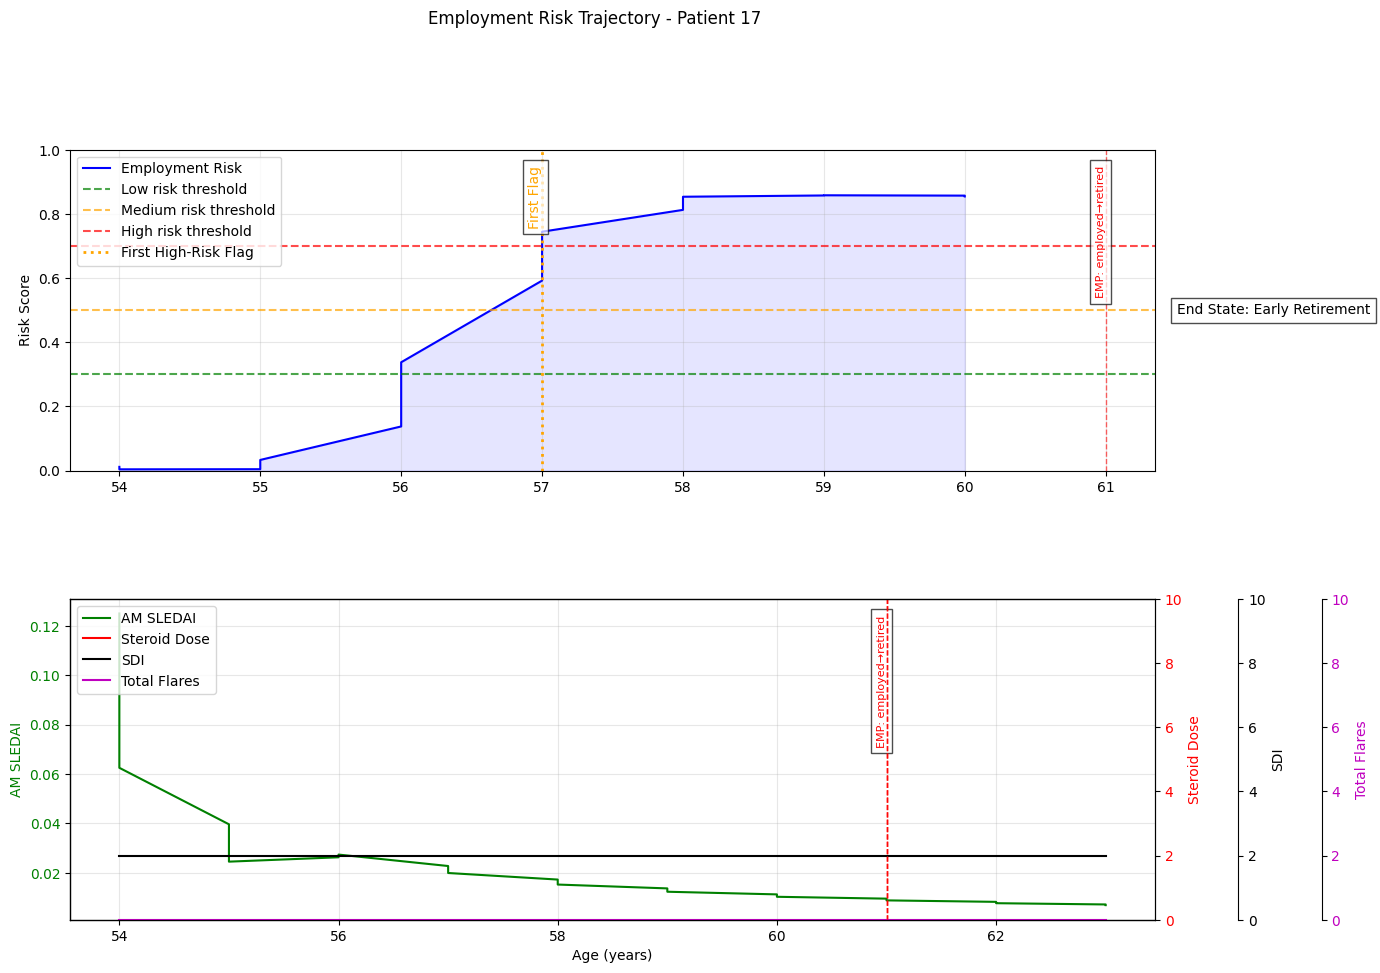


Displaying patient 24 (2/53)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_39031/1302998630.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


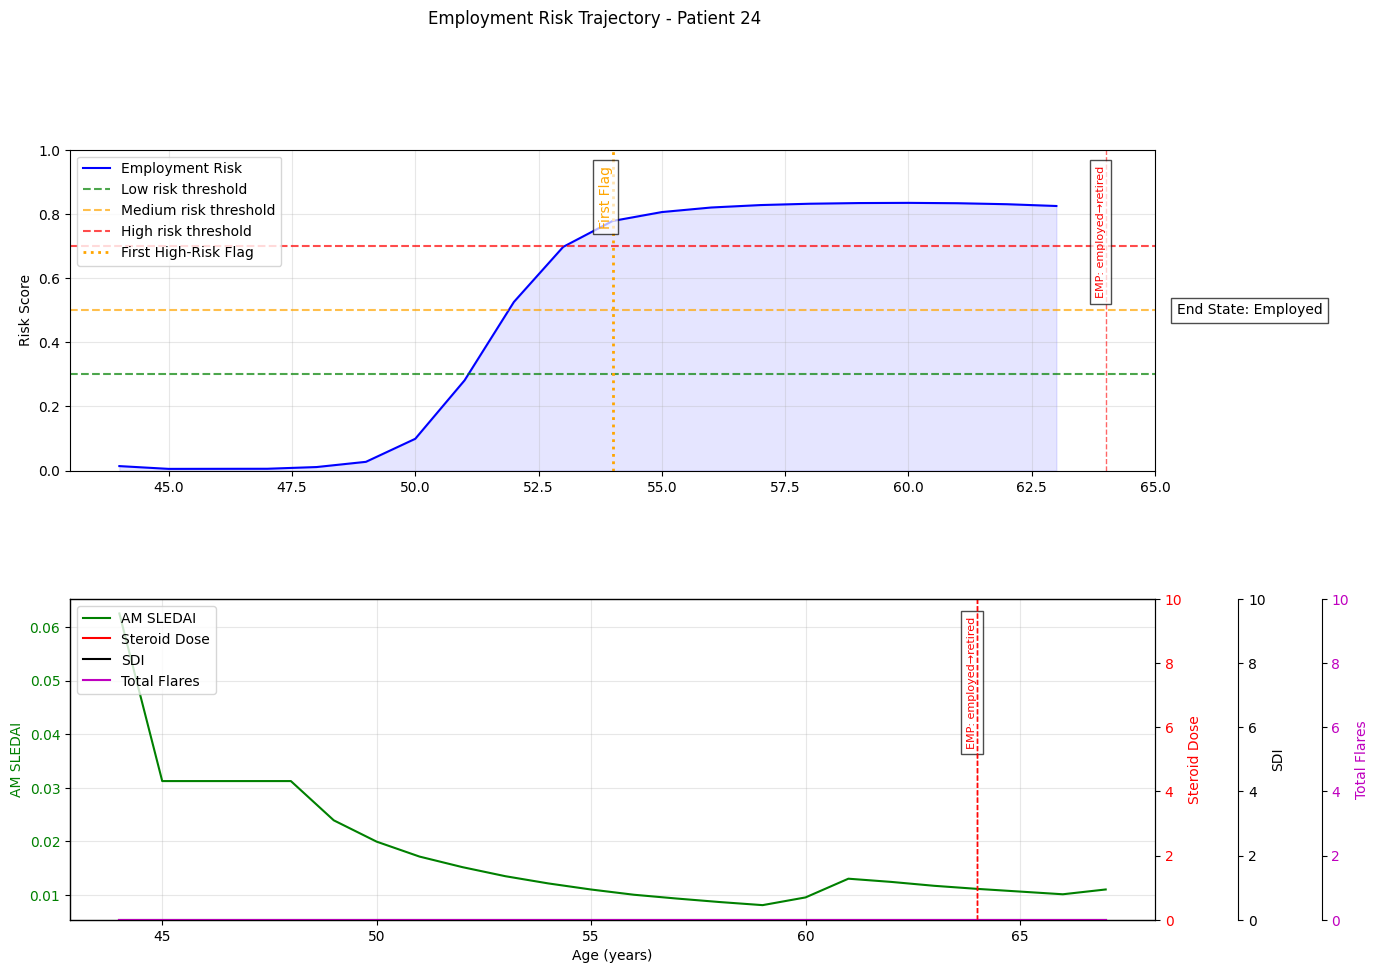


Displaying patient 34 (3/53)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_39031/1302998630.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


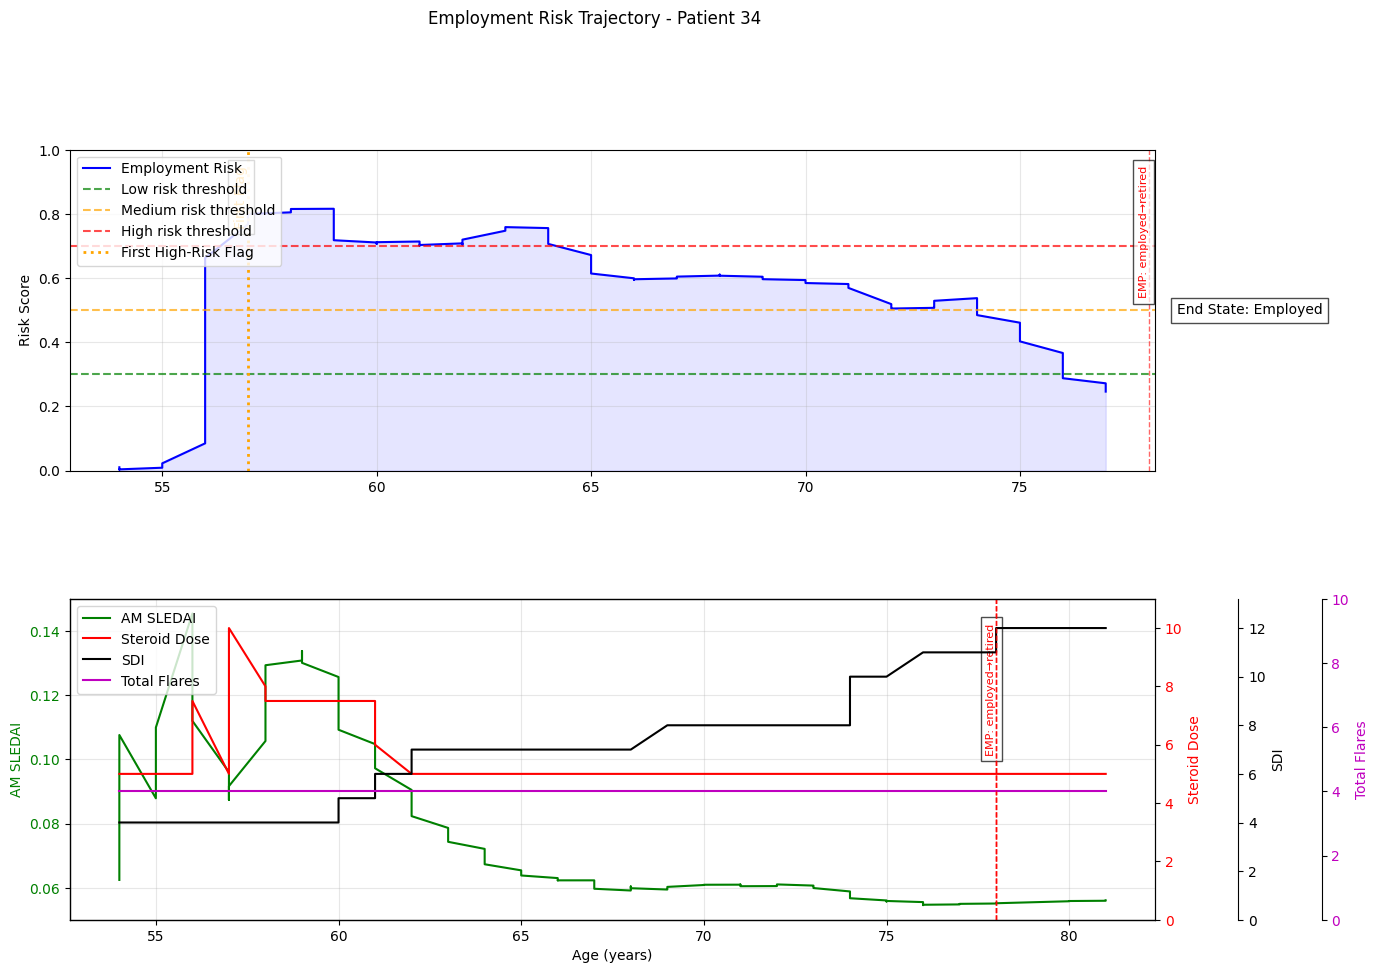


Displaying patient 44 (4/53)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_39031/1302998630.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


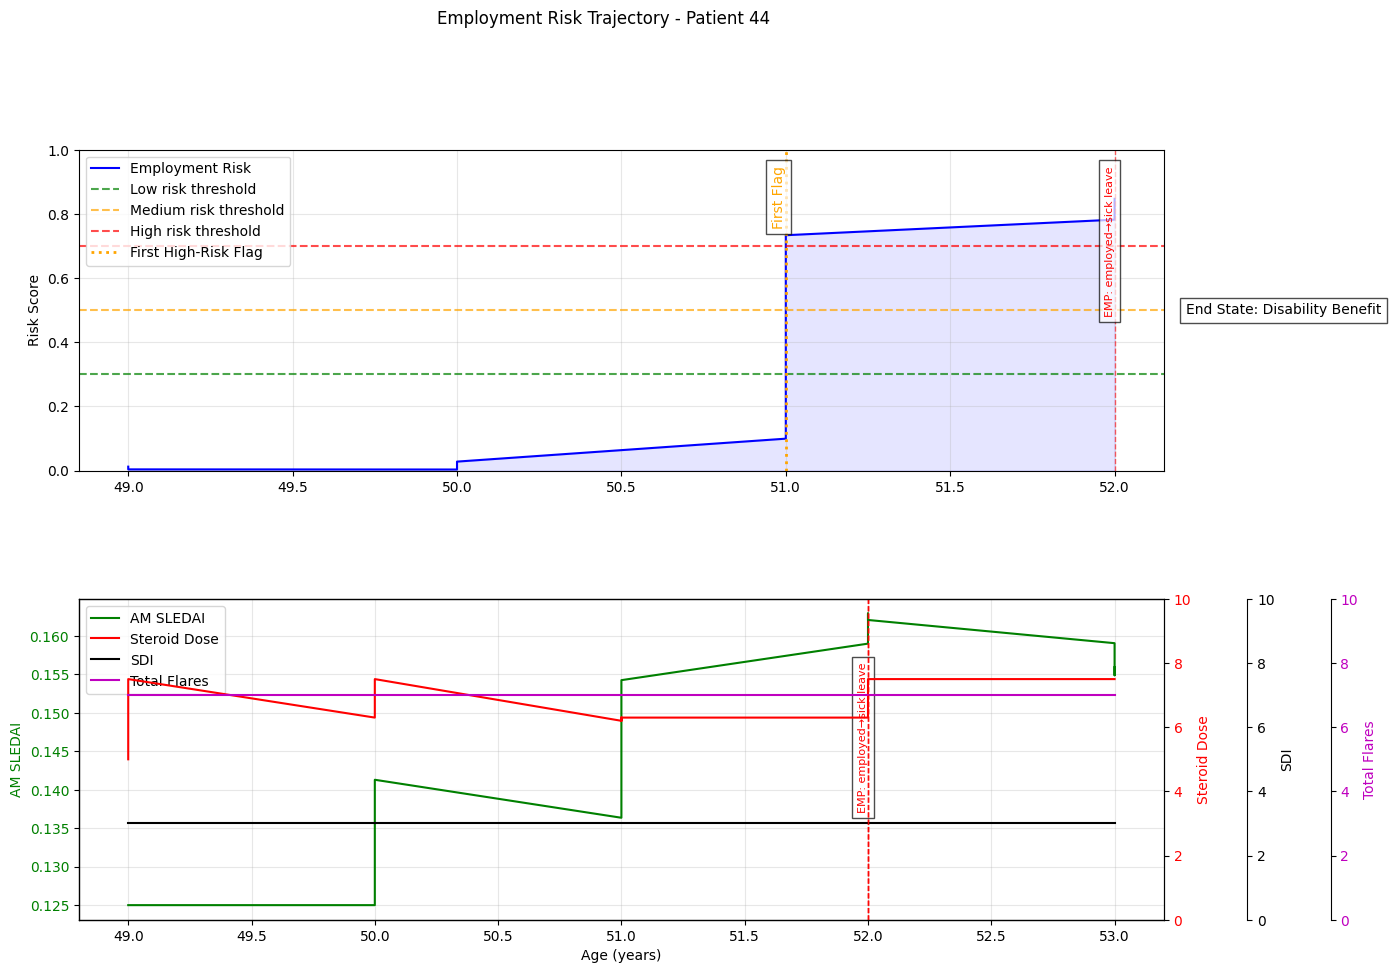


Displaying patient 69 (5/53)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_39031/1302998630.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


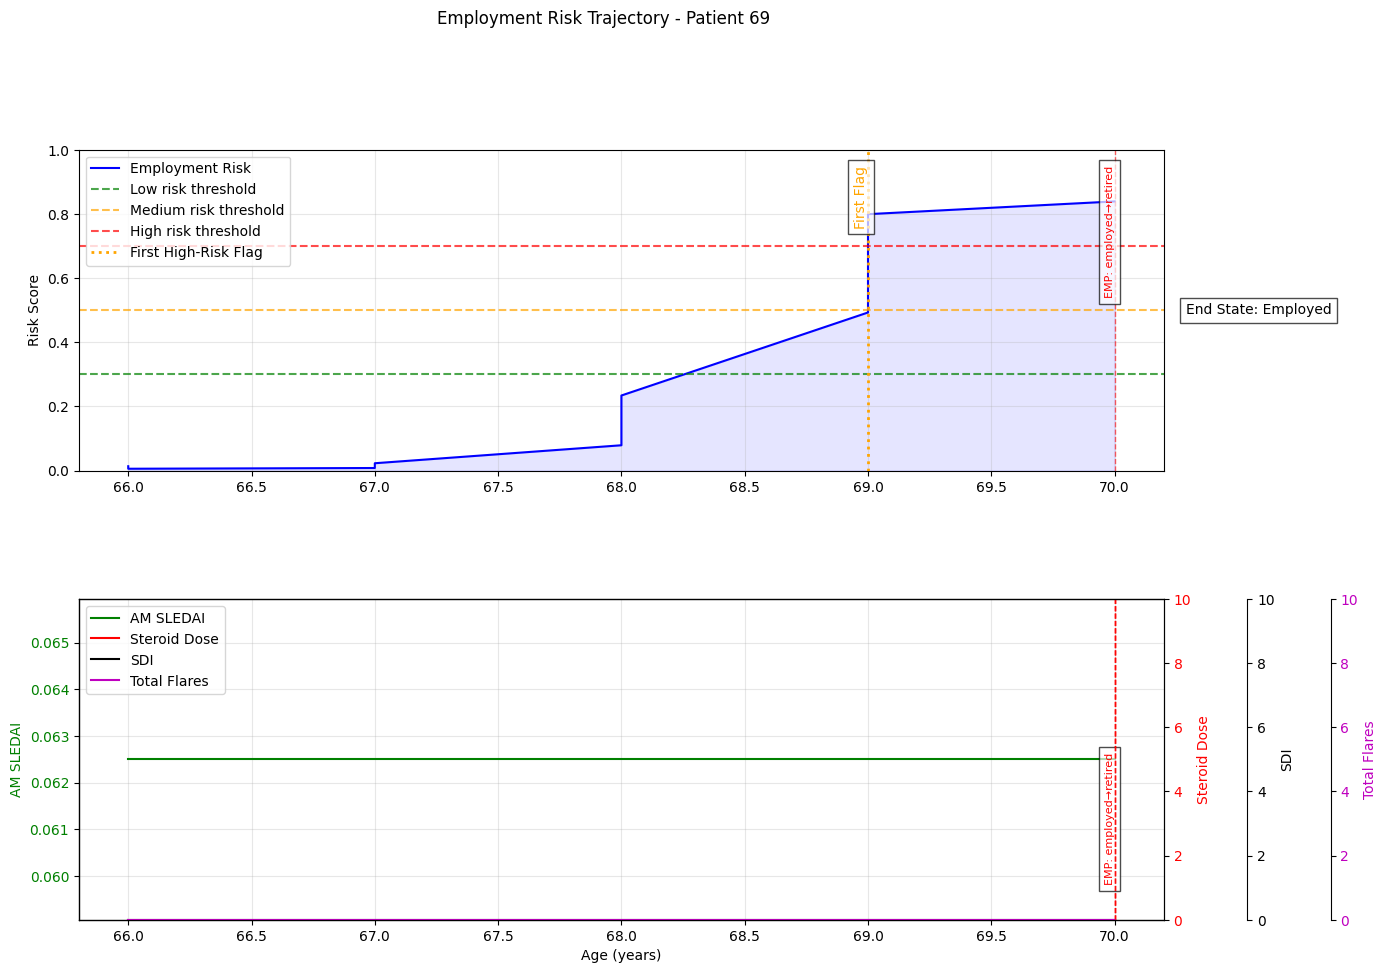


Displaying patient 95 (6/53)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_39031/1302998630.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


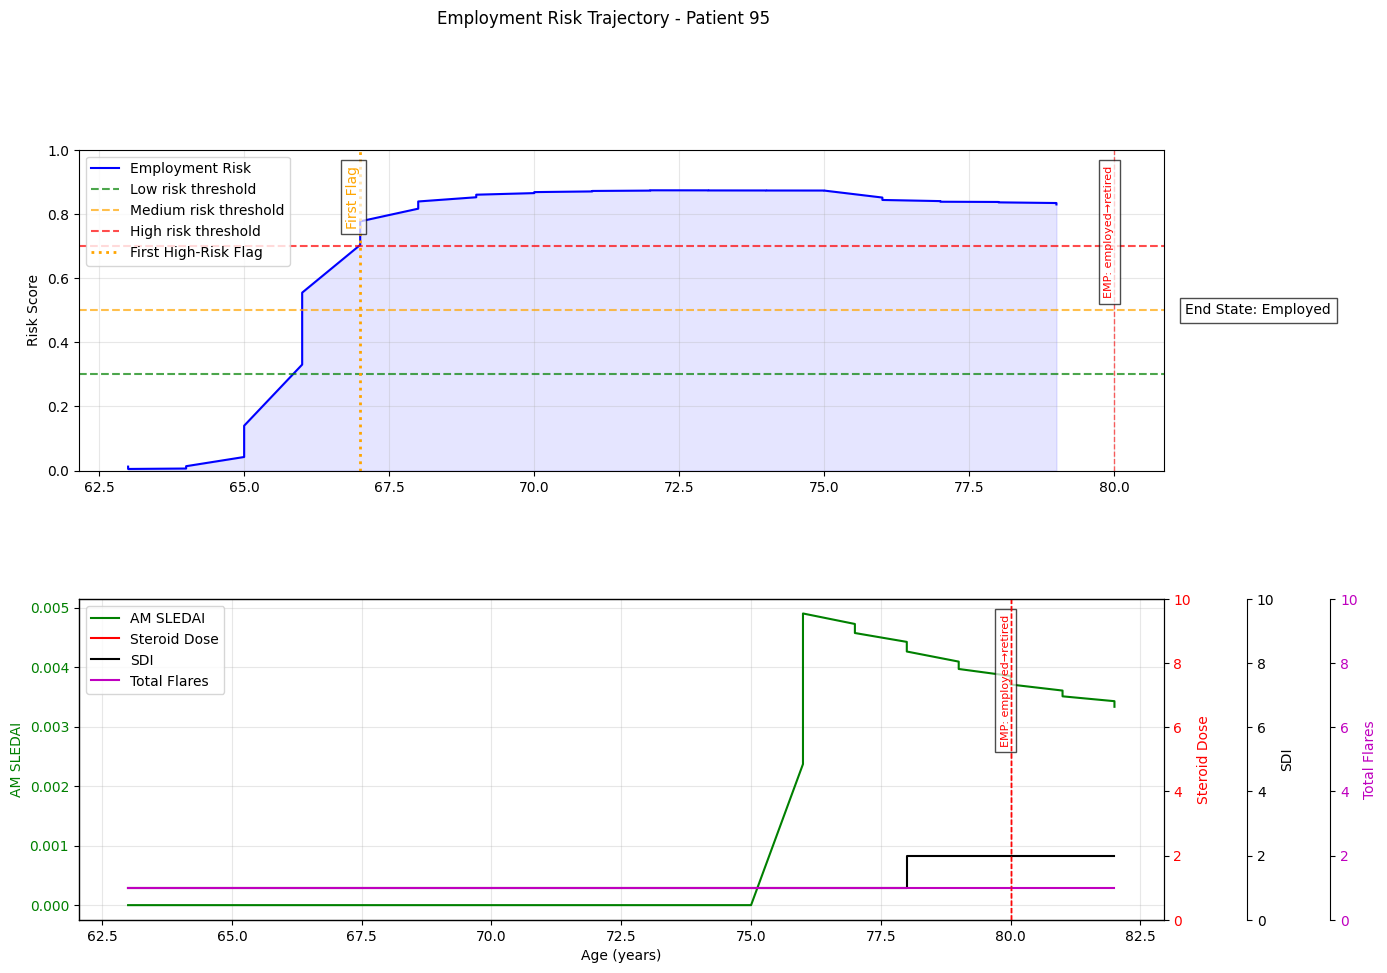


Displaying patient 96 (7/53)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_39031/1302998630.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


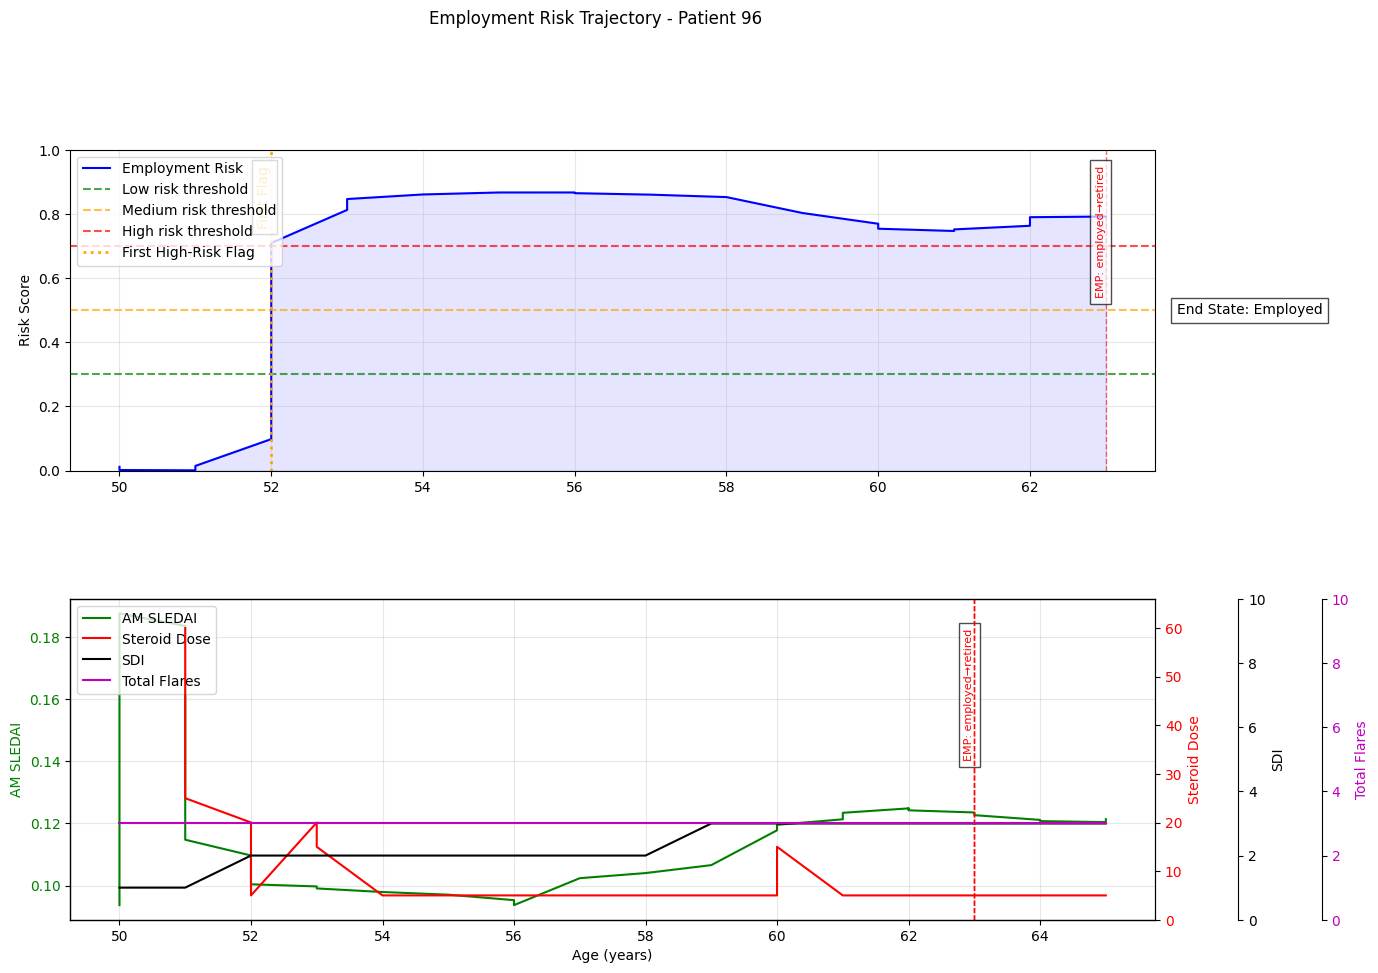


Displaying patient 135 (8/53)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_39031/1302998630.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


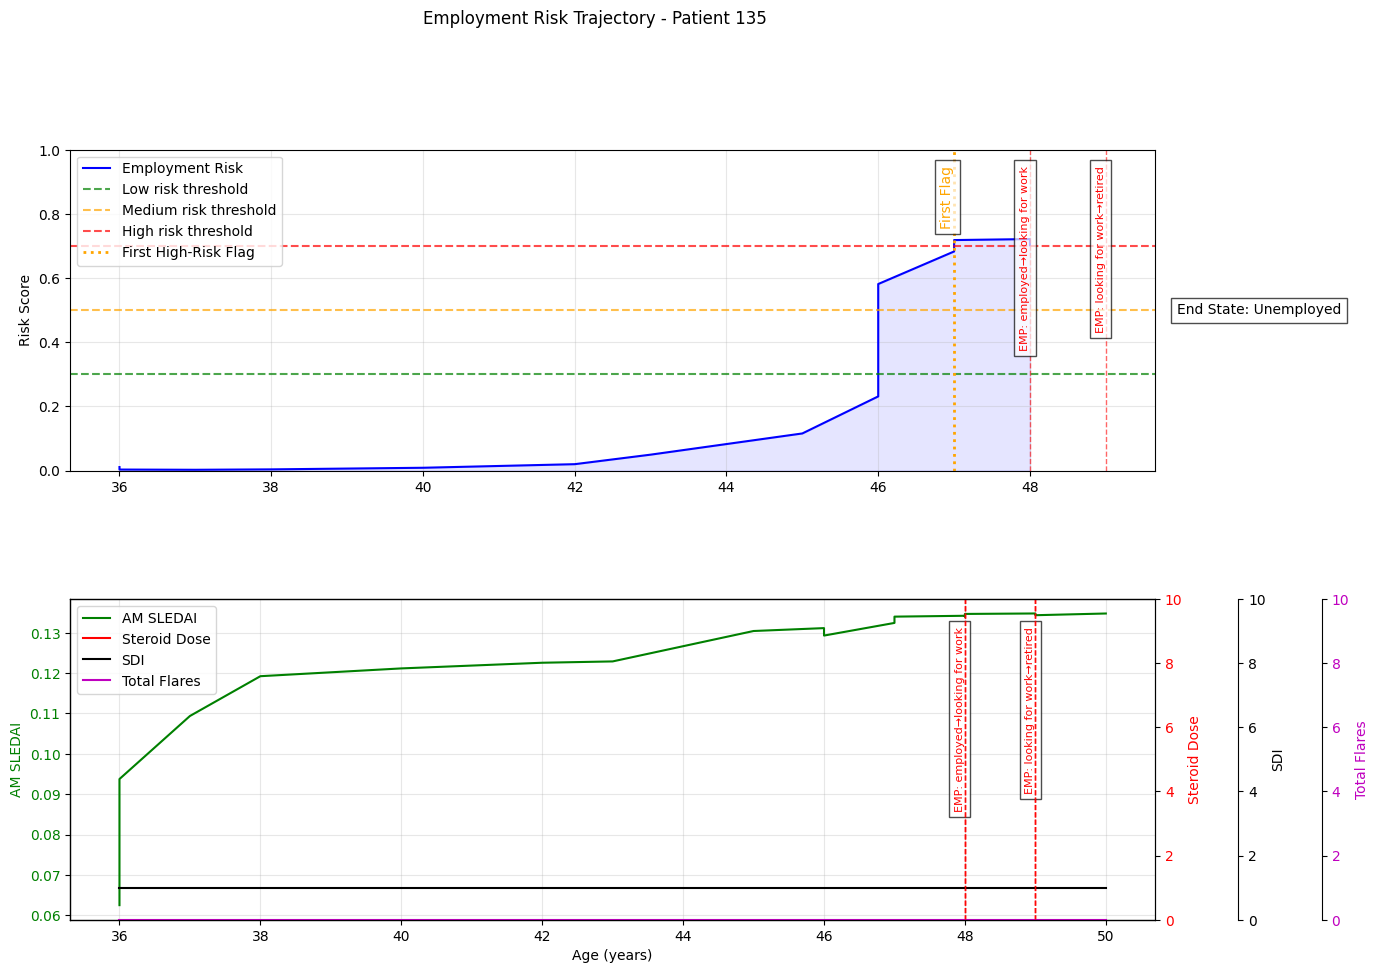


Displaying patient 140 (9/53)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_39031/1302998630.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


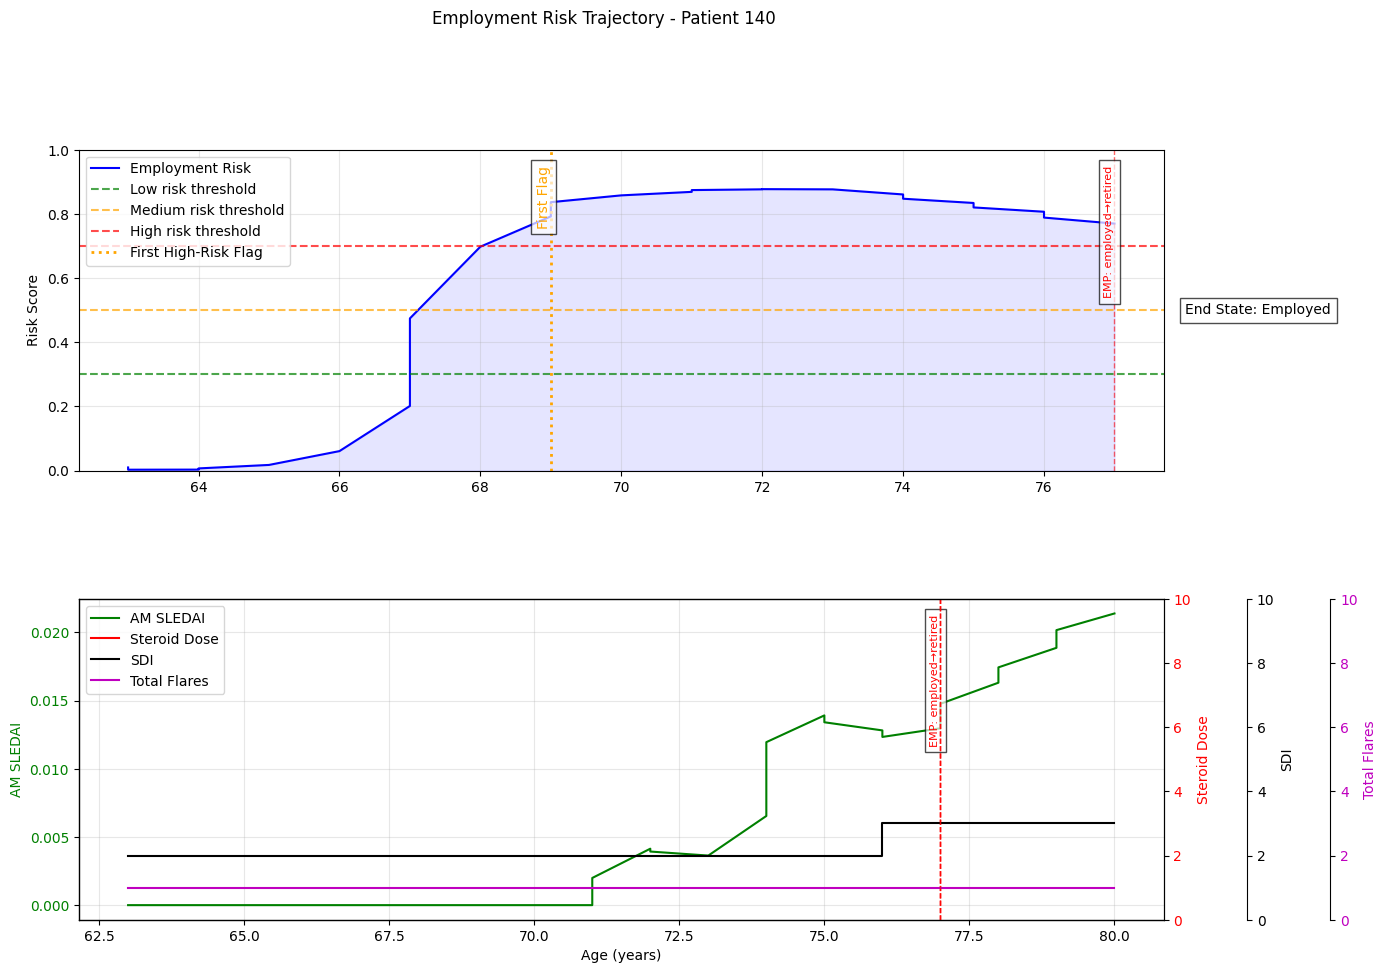


Displaying patient 141 (10/53)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_39031/1302998630.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


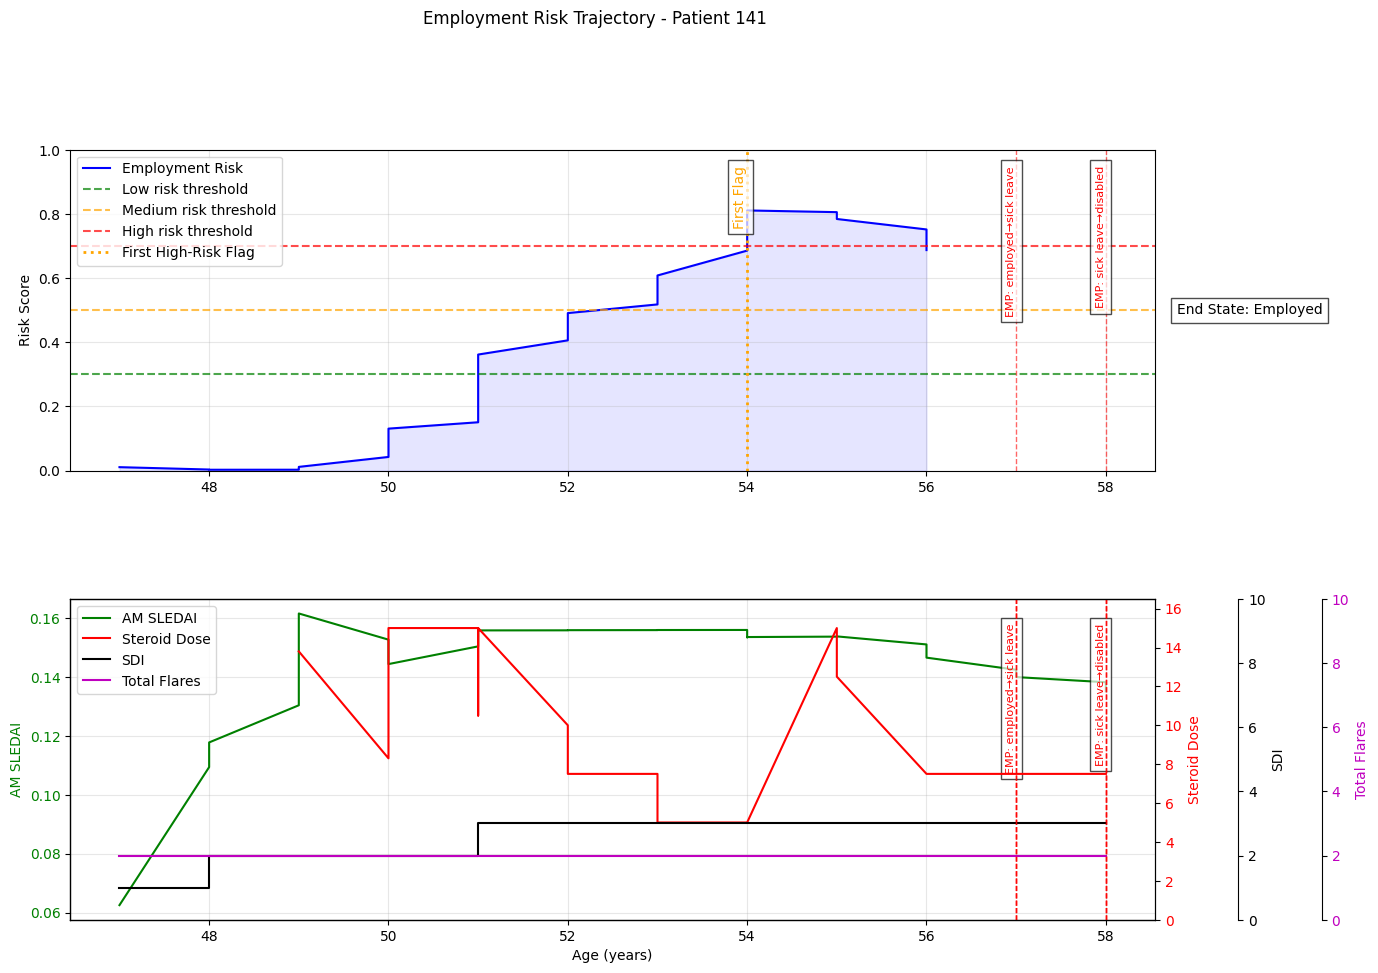


All patient trajectories displayed.


In [73]:
def plot_risk_trajectory(ptno, risk_df, clinical_data, origdata, risk_thresholds=None):
    """
    Generate and display a comprehensive risk trajectory plot for a single patient
    with age on x-axis, markers for employment status changes, and clinical predictors
    combined in one plot with separate y-axes.
    
    Parameters:
    - ptno: Patient ID
    - risk_df: DataFrame containing risk data with columns: 'ASSDT', 'enhanced_risk'
    - clinical_data: DataFrame containing clinical data with columns: 'ASSDT', 'age_at_record', 'EMP', and optionally 'AMS', 'STERDOSE', 'score_n'
    - origdata: DataFrame containing original unscaled data
    - risk_thresholds: Dictionary of risk thresholds (default is {'low': 0.3, 'medium': 0.5, 'high': 0.7})
    """
    if risk_thresholds is None:
        risk_thresholds = {'low': 0.3, 'medium': 0.5, 'high': 0.7}
    
    if len(risk_df) == 0:
        print(f"No data available for patient {ptno}")
        return
        
    try:
        # Create figure with subplots - risk plot on top, clinical markers combined below
        fig = plt.figure(figsize=(14, 10))
        gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.4)
        ax1 = fig.add_subplot(gs[0])  # Risk plot on top
        ax2 = fig.add_subplot(gs[1])  # Combined clinical plot on bottom
        fig.suptitle(f'Employment Risk Trajectory - Patient {ptno}', y=1.02)
        
        # Get original unscaled data for this patient
        pt_origdata = origdata[origdata['PTNO'] == ptno].sort_values('ASSDT')
        
        # Replace scaled columns with original values
        if 'age_at_record' in pt_origdata.columns:
            clinical_data['age_at_record'] = pt_origdata['age_at_record'].values
        if 'score_n' in pt_origdata.columns:
            clinical_data['score_n'] = pt_origdata['score_n'].values
        if 'total_flares' in pt_origdata.columns:
            clinical_data['total_flares'] = pt_origdata['total_flares'].values
        
        # Verify required columns exist
        if 'age_at_record' not in clinical_data.columns:
            print(f"Age data not available for patient {ptno}")
            return
        
        # Get end_state if available
        end_state = clinical_data['end_state'].iloc[-1] if 'end_state' in clinical_data.columns else 'Unknown'
        
        # --- Data Preparation ---
        # Sort by date and calculate age
        clinical_data = clinical_data.sort_values('ASSDT').reset_index(drop=True)
        risk_df = risk_df.merge(clinical_data[['ASSDT', 'age_at_record']], 
                              on='ASSDT', how='left')
        
        # --- Risk Plot ---
        ax1.plot(risk_df['age_at_record'], risk_df['enhanced_risk'], 
                'b-', label='Employment Risk')
        ax1.fill_between(risk_df['age_at_record'], risk_df['enhanced_risk'], 
                        color='blue', alpha=0.1)
        
        # Helper function for threshold colors
        def _get_threshold_color(name):
            colors = {'low': 'green', 'medium': 'orange', 'high': 'red'}
            return colors.get(name, 'gray')
        
        # Add threshold lines
        for name, threshold in risk_thresholds.items():
            ax1.axhline(y=threshold, color=_get_threshold_color(name), 
                       linestyle='--', alpha=0.7,
                       label=f'{name.capitalize()} risk threshold')
        
        # Mark first high-risk flag
        high_risk_flags = risk_df[risk_df['enhanced_risk'] >= risk_thresholds['high']]
        if not high_risk_flags.empty:
            first_flag_age = high_risk_flags.iloc[0]['age_at_record']
            ax1.axvline(x=first_flag_age, color='orange', linestyle=':', 
                       linewidth=2, label='First High-Risk Flag')
            ax1.text(x=first_flag_age, y=0.95, s='First Flag', 
                    rotation=90, va='top', ha='right', color='orange',
                    bbox=dict(facecolor='white', alpha=0.7))
        
        ax1.set_ylabel('Risk Score')
        ax1.set_ylim(0, 1)
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)
        
        # Add end_state label on the right side of the top plot
        ax1.text(1.02, 0.5, f'End State: {end_state}', 
                transform=ax1.transAxes, va='center', ha='left', 
                bbox=dict(facecolor='white', alpha=0.7))
        
        # --- Combined Clinical Markers Plot ---
        # Create additional y-axes for each clinical predictor
        ax_ster = ax2.twinx() if 'STERDOSE' in clinical_data.columns else None
        ax_sdi = ax2.twinx() if 'score_n' in clinical_data.columns else None
        ax_total_flares = ax2.twinx() if 'total_flares' in clinical_data.columns else None

        # Offset the spines for the additional axes
        if ax_ster is not None:
            ax_ster.spines['right'].set_position(('outward', 0))  # First right axis
        if ax_sdi is not None:
            ax_sdi.spines['right'].set_position(('outward', 60))  # Second right axis
        if ax_total_flares is not None:
            ax_total_flares.spines['right'].set_position(('outward', 120))  # Third right axis
                
        # Plot AMS on primary y-axis (left)
        if 'AMS' in clinical_data.columns:
            ax2.plot(clinical_data['age_at_record'], clinical_data['AMS'],
                   'g-', label='AM SLEDAI')
            ax2.set_ylabel('AM SLEDAI', color='g')
            ax2.tick_params(axis='y', labelcolor='g')
        
        # Plot Steroid Dose on first secondary y-axis (right)
        if ax_ster is not None and 'STERDOSE' in clinical_data.columns:
            ax_ster.plot(clinical_data['age_at_record'], clinical_data['STERDOSE'],
                        'r-', label='Steroid Dose')
            ax_ster.set_ylabel('Steroid Dose', color='r')
            ax_ster.tick_params(axis='y', labelcolor='r')
            ax_ster.set_ylim(0, max(10, clinical_data['STERDOSE'].max() * 1.1))
        
        # Plot SDI on second secondary y-axis (right, offset)
        if ax_sdi is not None and 'score_n' in clinical_data.columns:
            ax_sdi.plot(clinical_data['age_at_record'], clinical_data['score_n'],
                       'k-', label='SDI')
            ax_sdi.set_ylabel('SDI', color='k')
            ax_sdi.tick_params(axis='y', labelcolor='k')
            ax_sdi.set_ylim(0, max(10, clinical_data['score_n'].max() * 1.1))

        if ax_total_flares is not None and 'total_flares' in clinical_data.columns:
            ax_total_flares.plot(clinical_data['age_at_record'], clinical_data['total_flares'],
                    'm-', label='Total Flares')  # Changed color to magenta
            ax_total_flares.set_ylabel('Total Flares', color='m')  # Match color to line
            ax_total_flares.tick_params(axis='y', labelcolor='m')
            ax_total_flares.set_ylim(0, max(10, clinical_data['total_flares'].max() * 1.1))
        
        ax2.set_xlabel('Age (years)')
        ax2.grid(True, alpha=0.3)
        
        # Combine legends from all clinical axes
        lines, labels = ax2.get_legend_handles_labels()
        if ax_ster is not None:
            lines2, labels2 = ax_ster.get_legend_handles_labels()
            lines += lines2
            labels += labels2
        if ax_sdi is not None:
            lines3, labels3 = ax_sdi.get_legend_handles_labels()
            lines += lines3
            labels += labels3
        if ax_total_flares is not None:
            lines4, labels4 = ax_total_flares.get_legend_handles_labels()
            lines += lines4
            labels += labels4

        if lines:  # Only add legend if there are any lines to show
            ax2.legend(lines, labels, loc='upper left')
        
        # --- Employment Status Changes ---
        # Clean EMP data and find all transitions
        clinical_data['EMP_clean'] = clinical_data['EMP'].fillna('Unknown').str.strip().str.lower()
        
        # Find all employment status changes (not just first loss)
        emp_changes = clinical_data[clinical_data['EMP_clean'] != clinical_data['EMP_clean'].shift()]
        
        # Mark all employment status changes
        for _, change in emp_changes.iterrows():
            try:
                change_age = change['age_at_record']
                change_status = change['EMP'].strip() if pd.notna(change['EMP']) else 'Unknown'
                
                # Skip if this is the first record (no previous status to compare)
                if change.name == 0:
                    continue
                    
                # Get previous status for label
                prev_status = clinical_data.loc[change.name - 1, 'EMP_clean'] if change.name > 0 else 'Unknown'
                
                # Vertical lines on all subplots
                for ax in [ax1, ax2]:
                    if ax is not None:
                        ax.axvline(x=change_age, color='red', linestyle='--', 
                                  linewidth=1, alpha=0.6)
                        
                        # Label with employment status change
                        ax.text(x=change_age, y=ax.get_ylim()[1]*0.95, 
                               s=f"EMP: {prev_status}→{change_status}", rotation=90,
                               va='top', ha='right', color='red', fontsize=8,
                               bbox=dict(facecolor='white', alpha=0.7))
                
                # Also add to secondary axes if they exist
                for ax in [ax_ster, ax_sdi, ax_total_flares]:
                    if ax is not None:
                        ax.axvline(x=change_age, color='red', linestyle='--', 
                                  linewidth=1, alpha=0.6)
            except Exception as e:
                print(f"Error processing employment change for patient {ptno}: {str(e)}")
                continue
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error generating plot for patient {ptno}: {str(e)}")

# Generate and display plots for all patients flagged while employed
try:
    risk_thresholds = {'low': 0.3, 'medium': 0.5, 'high': 0.7}
    high_risk_threshold = risk_thresholds['high']  # Use the local variable instead of analyzer
    flagged_patients = risk_results[risk_results['enhanced_risk'] >= high_risk_threshold]['PTNO'].unique()

    print(f"Displaying trajectories for {len(flagged_patients)} patients flagged while employed...")
    print("Close each figure to see the next one.")

    for i, ptno in enumerate(flagged_patients[:10]):
        pt_risk = risk_results[risk_results['PTNO'] == ptno].sort_values('ASSDT')
        pt_clinical = data[data['PTNO'] == ptno].sort_values('ASSDT')
        
        print(f"\nDisplaying patient {ptno} ({i+1}/{len(flagged_patients)})")
        risk_thresholds = {'low': 0.3, 'medium': 0.5, 'high': 0.7}
        plot_risk_trajectory(ptno, pt_risk, pt_clinical, origdata, risk_thresholds)
        
    print("\nAll patient trajectories displayed.")
except Exception as e:
    print(f"Error in processing patients: {str(e)}")

In [54]:
data.columns.tolist()

['PTNO',
 'BIRTHDT',
 'SEX',
 'DATEOFDX',
 'RACE',
 'LCDT',
 'STATUS',
 'DEATHDT',
 'INCEPT',
 'ID',
 'ASSDT',
 'EMP',
 'visit_num',
 'total_visits',
 'startdate',
 'time_first_last',
 'time_between',
 'EMPf',
 'initial_emp',
 'final_emp',
 'visit_num96',
 'total_visits96',
 'time_first_last96',
 'time_between96',
 'changed',
 'time_to_first_change',
 'SLED1_I',
 'SLED2_I',
 'SLED3_I',
 'SLED4_I',
 'SLED5_I',
 'SLED6_I',
 'SLED7_I',
 'SLED8_I',
 'SLED9_I',
 'SLED10_I',
 'SLED11_I',
 'SLED12_I',
 'SLED13_I',
 'SLED14_I',
 'SLED15_I',
 'SLED16_I',
 'SLED17_I',
 'SLED18_I',
 'SLED19_I',
 'SLED20_I',
 'SLED21_I',
 'SLED22_I',
 'SLED23_I',
 'SLED24_I',
 'SLEDAI2_I',
 'ACATARACT',
 'RETOPT',
 'COGNIMP',
 'SEIZURX6',
 'CERVASAC',
 'CPNEUR',
 'TRANMYEL',
 'GFR50',
 'PROT24',
 'ENDRENAL',
 'PULMHYP',
 'PULMFIBR',
 'SHRINKL',
 'PLEURFIBR',
 'PULMINF',
 'ANGBYP',
 'MYOCARINF',
 'CARDMYOP',
 'VALVULAR',
 'PERICARD6',
 'CLAUDIC',
 'MINORTL',
 'SIGNIFTL',
 'VENTHROMB',
 'INFRESEC',
 'MESENINS',
 'PE